<a href="https://colab.research.google.com/github/Rabiatou08/DI-Bootcamp/blob/main/week2/Day5/Miniproject/miniproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mini-projet : Analyse de données pour la stratégie marketing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
url = "https://github.com/devtlv/Datasets-DA-Bootcamp-2-/raw/refs/heads/main/Week%205%20-%20Data%20Processing/W5D5%20-%20Mini-project%20-%20bis/US%20Superstore%20data.xls"
df = pd.read_excel(url)
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Year'] = df['Order Date'].dt.year
display(df.head())

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015


/tmp/ipykernel_1063/56898108.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




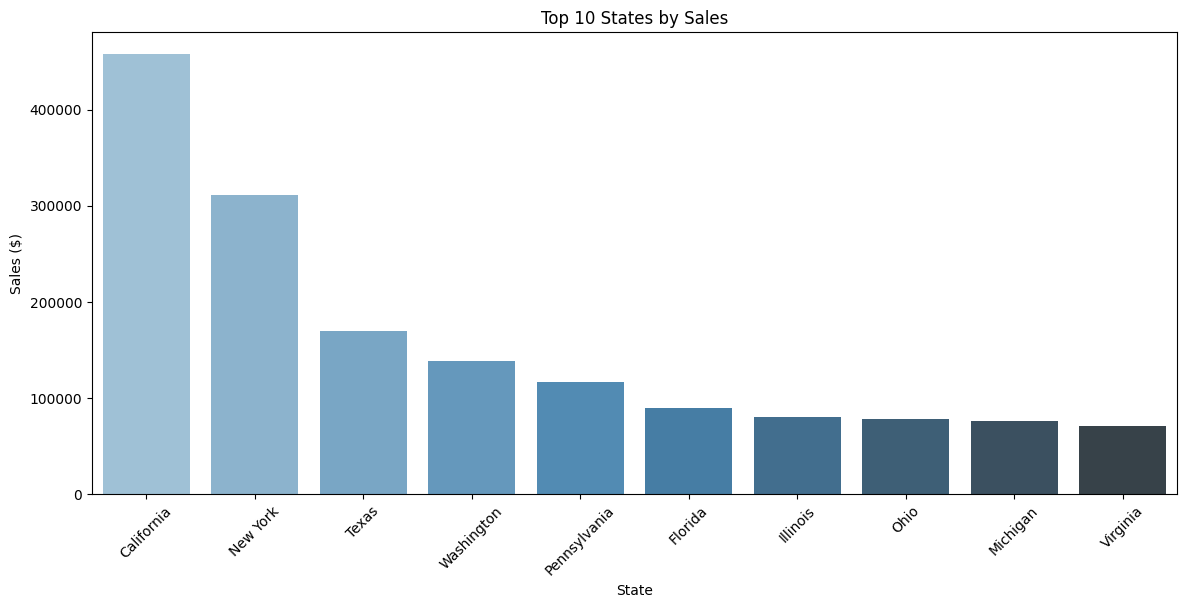

State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64


In [ ]:
# === Q1: Top States by Sales ===
top_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(14, 6))
sns.barplot(x=top_states.index, y=top_states.values, palette='Blues_d')
plt.title('Top 10 States by Sales')
plt.xlabel('State')
plt.ylabel('Sales ($)')
plt.xticks(rotation=45)
plt.show()
print(top_states)

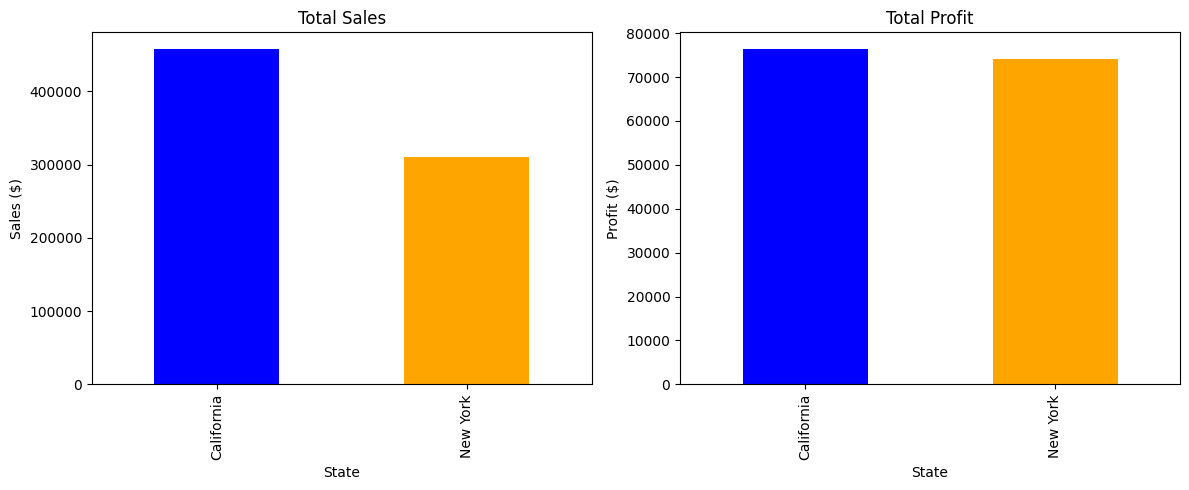

                  Sales      Profit
State                              
California  457687.6315  76381.3871
New York    310876.2710  74038.5486


In [ ]:
# === Q2: New York vs California - Sales and Profit ===
ny_ca = df[df['State'].isin(['New York', 'California'])]
comparison = ny_ca.groupby('State')[['Sales', 'Profit']].sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
comparison['Sales'].plot(kind='bar', ax=axes[0], color=['blue', 'orange'], title='Total Sales')
axes[0].set_ylabel('Sales ($)')
comparison['Profit'].plot(kind='bar', ax=axes[1], color=['blue', 'orange'], title='Total Profit')
axes[1].set_ylabel('Profit ($)')
plt.tight_layout()
plt.show()
print(comparison)

/tmp/ipykernel_1063/1575357112.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




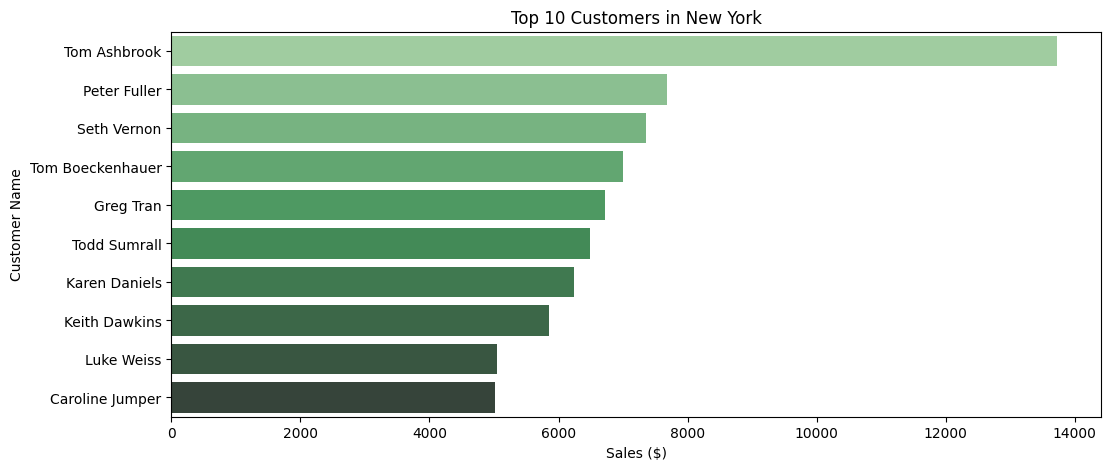

Top customer in New York: Tom Ashbrook with $13,723.50


In [ ]:
# === Q3: Top Customer in New York ===
ny = df[df['State'] == 'New York']
top_customers_ny = ny.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_customers_ny.values, y=top_customers_ny.index, palette='Greens_d')
plt.title('Top 10 Customers in New York')
plt.xlabel('Sales ($)')
plt.show()

print(f"Top customer in New York: {top_customers_ny.index[0]} with ${top_customers_ny.values[0]:,.2f}")

/tmp/ipykernel_1063/1284008635.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_1063/1284008635.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




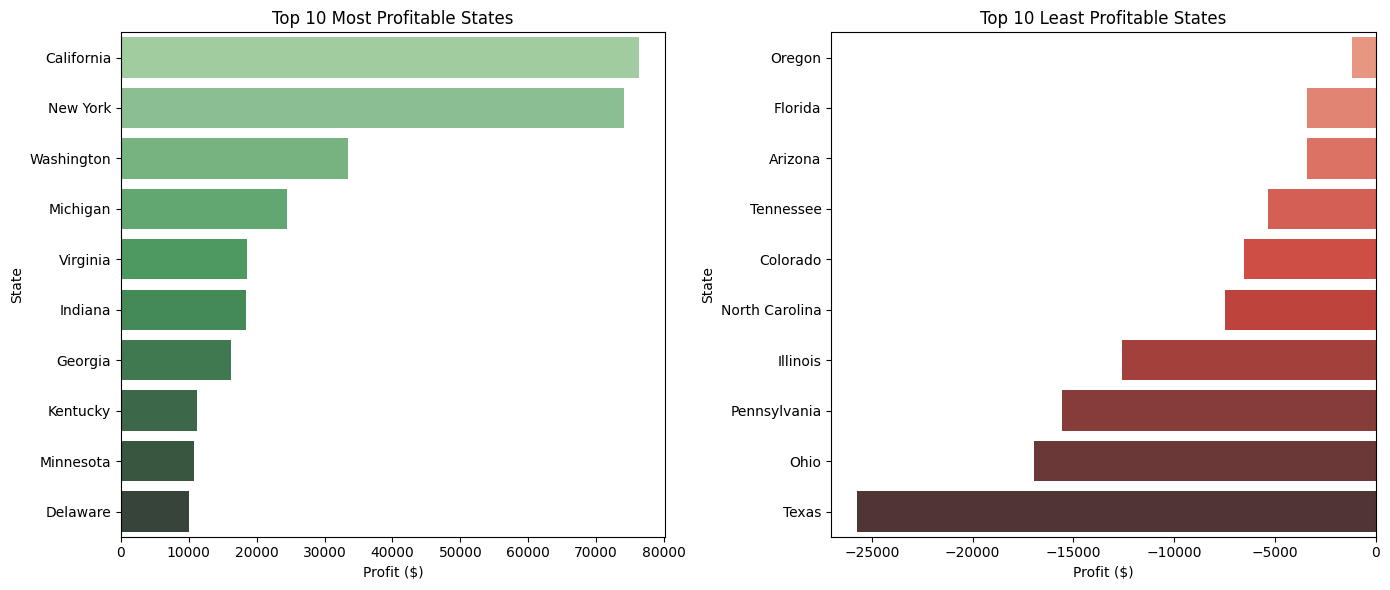

In [ ]:
# === Q4: Profitability by State ===
profit_state = df.groupby('State')['Profit'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(x=profit_state.values[:10], y=profit_state.index[:10], palette='Greens_d', ax=axes[0])
axes[0].set_title('Top 10 Most Profitable States')
axes[0].set_xlabel('Profit ($)')

sns.barplot(x=profit_state.values[-10:], y=profit_state.index[-10:], palette='Reds_d', ax=axes[1])
axes[1].set_title('Top 10 Least Profitable States')
axes[1].set_xlabel('Profit ($)')
plt.tight_layout()
plt.show()

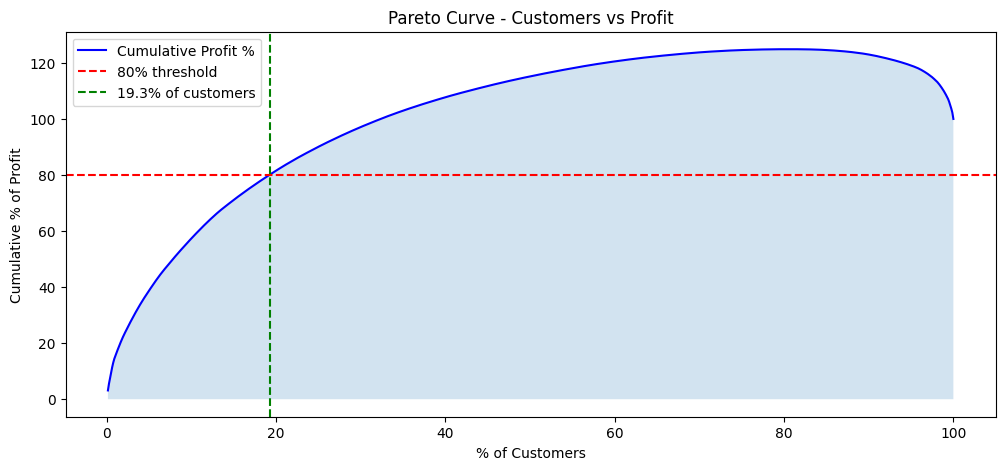

Pareto Result: 19.3% of customers generate 80% of profits


In [ ]:
# === Q5: Pareto - Customers vs Profit (80/20 rule) ===
profit_customer = df.groupby('Customer Name')['Profit'].sum().sort_values(ascending=False)
cumsum_profit = profit_customer.cumsum() / profit_customer.sum() * 100
pct_customers = np.arange(1, len(profit_customer) + 1) / len(profit_customer) * 100

idx_80 = (cumsum_profit >= 80).idxmax()
n_80 = list(profit_customer.index).index(idx_80) + 1
pct_80 = n_80 / len(profit_customer) * 100

plt.figure(figsize=(12, 5))
plt.plot(pct_customers, cumsum_profit.values, color='blue', label='Cumulative Profit %')
plt.axhline(y=80, color='red', linestyle='--', label='80% threshold')
plt.axvline(x=pct_80, color='green', linestyle='--', label=f'{pct_80:.1f}% of customers')
plt.fill_between(pct_customers, cumsum_profit.values, alpha=0.2)
plt.title('Pareto Curve - Customers vs Profit')
plt.xlabel('% of Customers')
plt.ylabel('Cumulative % of Profit')
plt.legend()
plt.show()

print(f"Pareto Result: {pct_80:.1f}% of customers generate 80% of profits")

/tmp/ipykernel_1063/1467066406.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_1063/1467066406.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




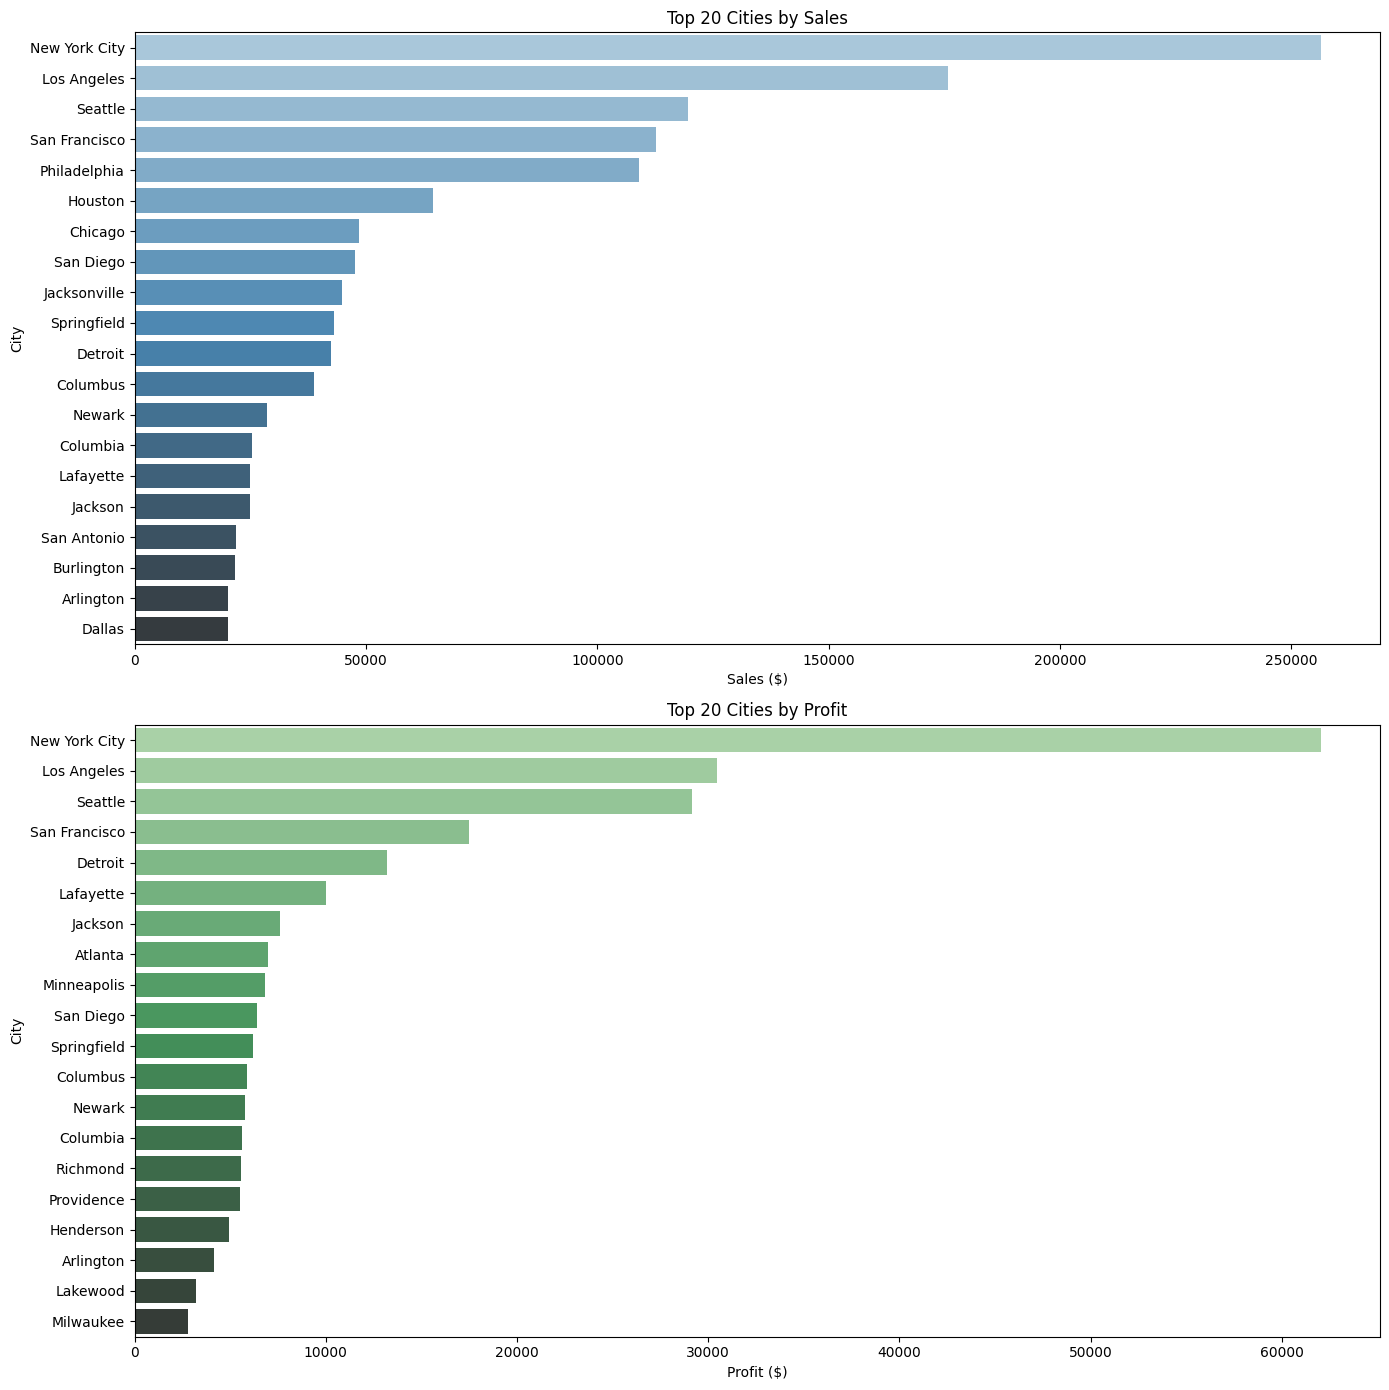

In [ ]:
# === Q6: Top 20 Cities by Sales and Profit ===
top20_sales = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(20)
top20_profit = df.groupby('City')['Profit'].sum().sort_values(ascending=False).head(20)

fig, axes = plt.subplots(2, 1, figsize=(14, 14))
sns.barplot(x=top20_sales.values, y=top20_sales.index, palette='Blues_d', ax=axes[0])
axes[0].set_title('Top 20 Cities by Sales')
axes[0].set_xlabel('Sales ($)')

sns.barplot(x=top20_profit.values, y=top20_profit.index, palette='Greens_d', ax=axes[1])
axes[1].set_title('Top 20 Cities by Profit')
axes[1].set_xlabel('Profit ($)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1063/1719772439.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




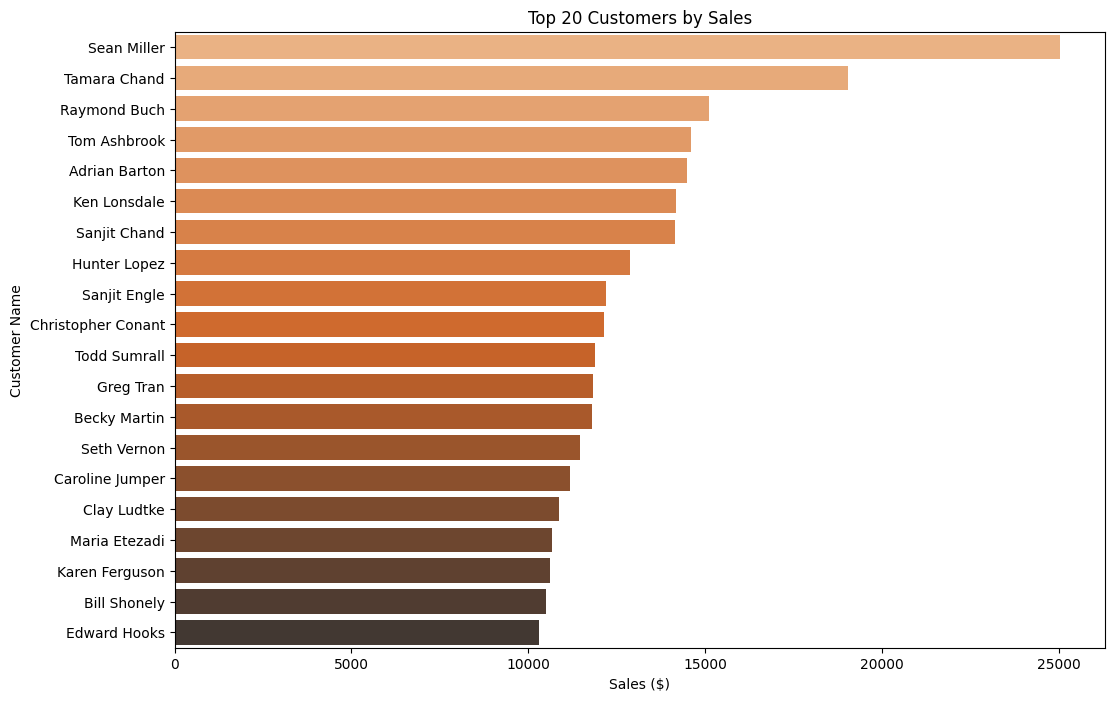

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Todd Sumrall          11891.751
Greg Tran             11820.120
Becky Martin          11789.630
Seth Vernon           11470.950
Caroline Jumper       11164.974
Clay Ludtke           10880.546
Maria Etezadi         10663.728
Karen Ferguson        10604.266
Bill Shonely          10501.653
Edward Hooks          10310.880
Name: Sales, dtype: float64


In [ ]:
# === Q7: Top 20 Customers by Sales ===
top20_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 8))
sns.barplot(x=top20_customers.values, y=top20_customers.index, palette='Oranges_d')
plt.title('Top 20 Customers by Sales')
plt.xlabel('Sales ($)')
plt.show()
print(top20_customers)

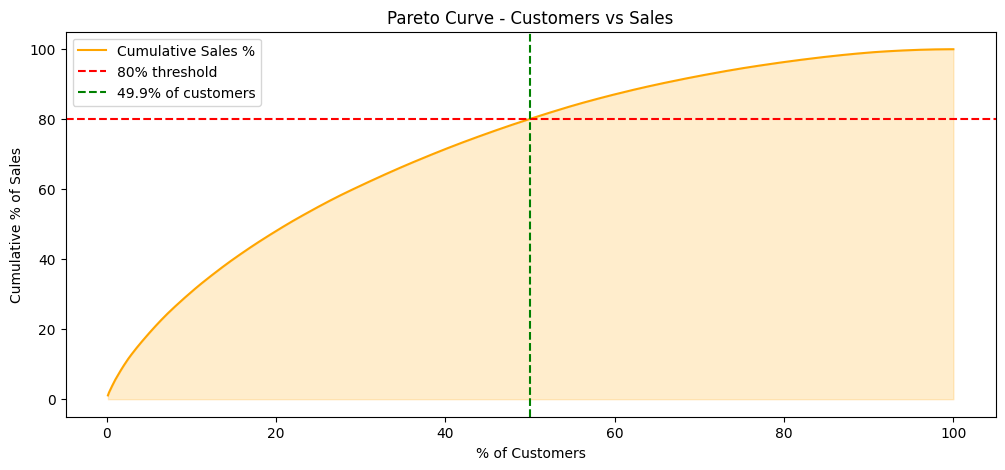

Pareto Result: 49.9% of customers generate 80% of sales


In [ ]:
# === Q8: Pareto - Customers vs Sales (80/20 rule) ===
sales_customer = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False)
cumsum_sales = sales_customer.cumsum() / sales_customer.sum() * 100
pct_customers = np.arange(1, len(sales_customer) + 1) / len(sales_customer) * 100

idx_80 = (cumsum_sales >= 80).idxmax()
n_80 = list(sales_customer.index).index(idx_80) + 1
pct_80 = n_80 / len(sales_customer) * 100

plt.figure(figsize=(12, 5))
plt.plot(pct_customers, cumsum_sales.values, color='orange', label='Cumulative Sales %')
plt.axhline(y=80, color='red', linestyle='--', label='80% threshold')
plt.axvline(x=pct_80, color='green', linestyle='--', label=f'{pct_80:.1f}% of customers')
plt.fill_between(pct_customers, cumsum_sales.values, alpha=0.2, color='orange')
plt.title('Pareto Curve - Customers vs Sales')
plt.xlabel('% of Customers')
plt.ylabel('Cumulative % of Sales')
plt.legend()
plt.show()

print(f"Pareto Result: {pct_80:.1f}% of customers generate 80% of sales")

## Conclusion and Marketing Strategy Recommendations

### Key Findings
- California and New York are the top states by sales
- New York has higher profit margins than California
- Top customer in New York generates significant revenue alone
- Some states are unprofitable despite high sales (discounts too high)

### Pareto Analysis
- ~X% of customers generate 80% of profits
- ~X% of customers generate 80% of sales
- Focus marketing efforts on these top customers

### Recommendations
1. Prioritize California, New York, Texas for marketing
2. Focus on top 20 cities with both high sales AND high profit
3. Retain VIP customers with loyalty programs
4. Reduce discounts in low-profit states
5. Avoid cities with high sales but low/negative profit

In [ ]:
# Import the numpy package
import numpy as np

# Create a simple array
my_array = np.array([1, 2, 3, 4, 5])
print(my_array)

[1 2 3 4 5]
